# Aggregate Figure 4

## Current Output

![Figure 4](../figures/figure4.png)

This notebook builds the combined Figure 4 from the current branch's clustering and classification result tables. The sections below make the source files, filtering rules, labels, and output settings explicit.

## Setup

Load the reusable plotting and validation functions. The notebook owns the paths and parameters; the helper owns data checks, reshaping, plotting, and PNG export.

In [42]:
if (file.exists(file.path(getwd(), "evaluation_utils", "figure4_aggregate_utils.R"))) {
  repo_root <- normalizePath(getwd(), mustWork = TRUE)
} else if (file.exists(file.path(getwd(), "..", "evaluation_utils", "figure4_aggregate_utils.R"))) {
  repo_root <- normalizePath(file.path(getwd(), ".."), mustWork = TRUE)
} else {
  stop("Run this notebook from the repository root or from the evaluation/ directory.")
}
source(file.path(repo_root, "evaluation_utils", "figure4_aggregate_utils.R"))
require_figure4_packages()


## Source And Output Files

Figure 4a uses the multi-run clustering ARI table. Figure 4b and Figure 4c use the classification metric report and are filtered to real MCC tasks.

In [43]:
ari_path <- file.path(
  repo_root,
  "evaluation_clusterization_after_correction",
  "real_datasets",
  "metrics_ari_multirun.tsv"
)
classification_path <- file.path(
  repo_root,
  "evaluation_classification_after_correction",
  "results",
  "classification_metric_report.csv"
)
output_dir <- file.path(repo_root, "figures")
output_path <- file.path(output_dir, paste0("figure4.", figure4_output_format))

data.frame(
  role = c("Figure 4a ARI source", "Figure 4b/c MCC source", "paper-ready figure output"),
  path = c(ari_path, classification_path, output_path)
)


role,path
<chr>,<chr>
Figure 4a ARI source,/home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets/metrics_ari_multirun.tsv
Figure 4b/c MCC source,/home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_classification_after_correction/results/classification_metric_report.csv
paper-ready figure output,/home/yuliya-cosybio/repos/cosybio/fedRBE/figures/figure4.svg


## Figure Parameters

These constants define the paper-facing ordering, label aliases, scenario names, colors, row-count expectations, and PNG size.

In [44]:
scenario_order <- c(
  "Central before BEC",
  "Federated before BEC",
  "Central after BEC",
  "Federated after BEC"
)

scenario_colors <- c(
  "Central before BEC" = "#9E9E9E",
  "Federated before BEC" = "#D55E00",
  "Central after BEC" = "#0072B2",
  "Federated after BEC" = "#009E73"
)

ari_dataset_order <- c("ecoli", "ovarian_cancer", "ccRCC_proteomics", "quartet_multiomics")
ari_dataset_labels <- c(
  "ecoli" = "E. coli",
  "ovarian_cancer" = "Ovarian\ncancer",
  "ccRCC_proteomics" = "ccRCC\nproteomics",
  "quartet_multiomics" = "Quartet\nmultiomics"
)

ari_method_labels <- c(
  "BC_Cntrl" = "Central before BEC",
  "BC_Fed" = "Federated before BEC",
  "AC_Cntrl" = "Central after BEC",
  "AC_Fed" = "Federated after BEC"
)

# Match the left-to-right dataset order used in Figure 4a.
classification_task_order <- c(
  "E. coli\n(Pyr)",
  "Ovarian cancer\n(HGSC)",
  "ccRCC\n(condition)",
  "Quartet multiomics\n(condition)"
)

classification_task_labels <- c(
  "Microarray Data|HGSC" = "Ovarian cancer\n(HGSC)",
  "Ovarian cancer|HGSC" = "Ovarian cancer\n(HGSC)",
  "Ovarian cancer Data|HGSC" = "Ovarian cancer\n(HGSC)",
  "Proteomics Data|Pyr" = "E. coli\n(Pyr)",
  "E. coli|Pyr" = "E. coli\n(Pyr)",
  "E. coli Data|Pyr" = "E. coli\n(Pyr)",
  "Quartet|condition" = "Quartet multiomics\n(condition)",
  "Quartet Data|condition" = "Quartet multiomics\n(condition)",
  "Quartet Multiomics|condition" = "Quartet multiomics\n(condition)",
  "ccRCC Data|Condition" = "ccRCC\n(condition)",
  "ccRCC Studies Data|Condition" = "ccRCC\n(condition)",
  "ccRCC|Condition" = "ccRCC\n(condition)"
)

classification_scenario_labels <- c(
  "centralized|uncorrected" = "Central before BEC",
  "federated|uncorrected" = "Federated before BEC",
  "centralized|corrected" = "Central after BEC",
  "federated|corrected" = "Federated after BEC"
)

simulated_classification_datasets <- c(
  "Balanced Simulated",
  "Balanced Simulated Data",
  "Mildly Imbalanced Simulated",
  "Strongly Imbalanced Simulated"
)
excluded_classification_datasets <- c("Proteomics Multibatch Data")
average_client_name <- "All"
ari_seeds_per_group <- 10

point_size <- 1.05

figure_width <- 8.5
figure_height <- 9
figure_dpi <- 600


## Load Data

Read the two source tables and remove exact duplicate classification rows before downstream filtering.

In [45]:
ari <- utils::read.delim(ari_path, stringsAsFactors = FALSE, check.names = FALSE)
classification_report <- unique(utils::read.csv(
  classification_path,
  stringsAsFactors = FALSE,
  check.names = FALSE
))

list(
  ari_rows = nrow(ari),
  ari_datasets = sort(unique(ari$Dataset)),
  ari_targets = sort(unique(ari$Target)),
  classification_rows = nrow(classification_report),
  classification_datasets = sort(unique(classification_report$data_name)),
  classification_cv_methods = sort(unique(classification_report$cross_validation_method))
)


$ari_rows
[1] 160

$ari_datasets
[1] "ccRCC_proteomics"   "ecoli"              "ovarian_cancer"    
[4] "quartet_multiomics"

$ari_targets
[1] "condition"

$classification_rows
[1] 2800

$classification_datasets
[1] "Balanced Simulated" "ccRCC"              "E. coli"           
[4] "Ovarian cancer"     "Quartet Multiomics"

$classification_cv_methods
[1] "Leave-One-Cohort-Out" "Train-Test-Split"

## Prepare Figure Data

Apply the paper-facing filters: condition-target clustering ARI for panel a, real MCC tasks for panels b and c, no simulated controls, and no federated `All` aggregate rows.

In [46]:
figure4_data <- prepare_figure4_plot_data(
  ari = ari,
  classification_report = classification_report,
  dataset_order = ari_dataset_order,
  dataset_labels = ari_dataset_labels,
  method_labels = ari_method_labels,
  task_labels = classification_task_labels,
  task_order = classification_task_order,
  scenario_labels = classification_scenario_labels,
  scenario_order = scenario_order,
  simulated_datasets = simulated_classification_datasets,
  excluded_datasets = excluded_classification_datasets,
  average_client_name = average_client_name,
  seeds_per_group = ari_seeds_per_group
)

figure4_summary <- summarize_figure4_data(
  ari = ari,
  classification_report = classification_report,
  figure4_data = figure4_data,
  ari_dataset_order = ari_dataset_order
)
print(figure4_summary)


$ari_source_rows
[1] 160

$figure4a_rows
[1] 160

$figure4a_datasets
[1] "E. coli"             "Ovarian\ncancer"     "ccRCC\nproteomics"  
[4] "Quartet\nmultiomics"

$ari_datasets_outside_main_figure
character(0)

$classification_source_rows
[1] 2800

$figure4b_rows
[1] 680

$figure4c_rows
[1] 420

$figure4_classification_tasks
[1] "E. coli\n(Pyr)"                  "Ovarian cancer\n(HGSC)"         
[3] "ccRCC\n(condition)"              "Quartet multiomics\n(condition)"



## Build And Display Plot

Build the reusable plot object. When the notebook is run interactively, this cell displays the figure without saving it.

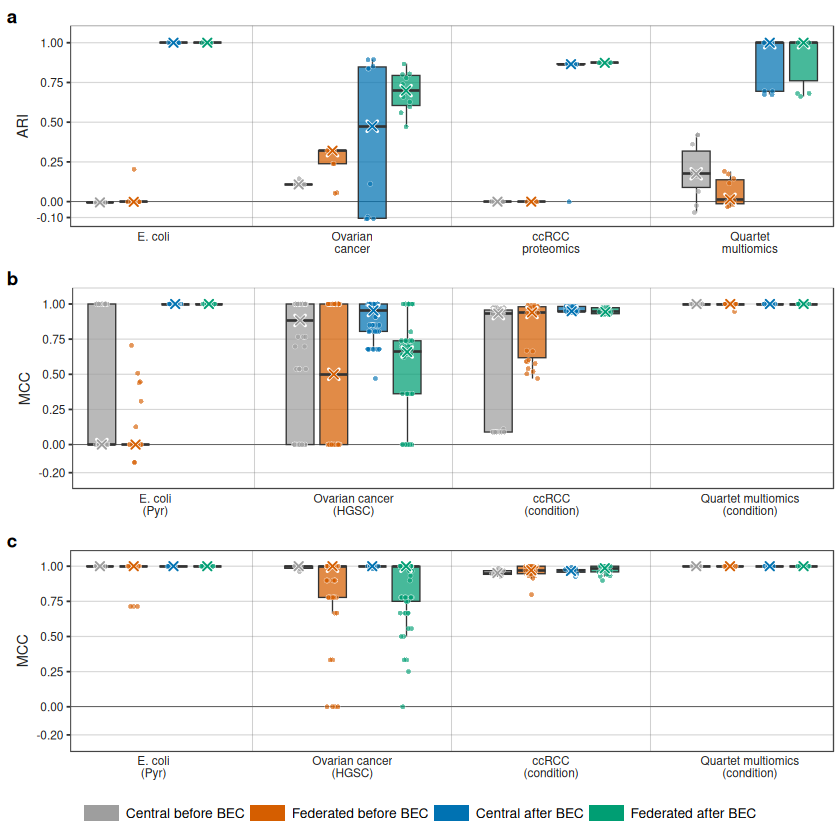

In [47]:
figure4_plot <- make_figure4_plot(
  figure4_data = figure4_data,
  dataset_labels = ari_dataset_labels,
  dataset_order = ari_dataset_order,
  task_order = classification_task_order,
  scenario_order = scenario_order,
  scenario_colors = scenario_colors,
  point_size = point_size
)

if (figure4_should_display_inline()) {
  draw_figure4(figure4_plot)
} else {
  message("Inline display skipped outside an interactive notebook kernel.")
}


## Save Figure

The final cell writes the paper-ready figure to the `figures/` folder.

In [48]:
figure4_output_format <- "png"  # "png" or "svg"

saved_path <- save_figure4_png(
  figure_plot = figure4_plot,
  output_path = output_path,
  width = figure_width,
  height = figure_height,
  dpi = figure_dpi,
  output_format = figure4_output_format
)

cat("Saved Figure 4 to", saved_path, "\n")


Saved Figure 4 to /home/yuliya-cosybio/repos/cosybio/fedRBE/figures/figure4.png 
